In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.io import loadmat, savemat
import datetime
from haversine import haversine, Unit
import pandas as pd
from windspharm.xarray import VectorWind
from scipy.fft import dst, idst
from matplotlib.ticker import StrMethodFormatter



# Overview of steps that need to be performed to generate currents

1. Need to match lat/lon bounds to the lat/lon bounds of the idealized model setup
2. Need to generate max inertial current time series
   -- This should be a sin wave with some variability in amplitude
4. Apply gaussian filter of desired spatial length scale

In [2]:

def make_gaussian(era5, sigma):
    """
    Input:
        sigma: spatial std of gaussian
        era: base .nc file (for example from era5 data product) with proper lat/lon range, and encompassing targe time frame.
        
    """

    x_size=len(era5.longitude)
    y_size=len(era5.latitude)
    x = np.linspace(-x_size/2, x_size/2, x_size)
    y = np.linspace(-y_size/2, y_size/2, y_size)
    # Create the 2D coordinate grids
    X, Y = np.meshgrid(x, y)
    D = np.sqrt((X)**2 + (Y)**2)
    spatial_decay = sigma
    
    ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, len(era5.latitude))
    xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, len(era5.longitude))
    dx = xkm[1]-xkm[0]
    dy = ykm[1]-ykm[0]
    
    sigma_x =  spatial_decay/(dx) # Standard deviation (controls spread) - converts from km units to in terms of grid points
    sigma_y = spatial_decay/(dy)
    #1deg lat=111km, so each coord is 0.25 deg, or ~28km
    xshift = 0
    yshift = 0
    gaussian = 1/(2*np.pi*sigma_x*sigma_y) * np.exp(-((X-xshift)**2 / (2.0 * sigma_x**2))-((Y-yshift)**2 / (2.0 * sigma_y**2)))
    max_val = np.max(gaussian)
    gaussian_2d = gaussian/max_val # This is to get gaussian from 0-1
    
    # Create the new shape for broadcasting
    # (num_reps, arr_2d.shape[0], arr_2d.shape[1])
    new_shape = (len(era5.time,), gaussian_2d.shape[0], gaussian_2d.shape[1])

    # Broadcast the 2D array to the new 3D shape
    gaussian_3d = np.broadcast_to(gaussian_2d, new_shape)

    return(gaussian_3d)

def make_gaussian_inertial_current(era5, Ti, sigma, amplitude, dim='2d', rot='cw'):
    """
    Input:
        sigma: spatial std of gaussian
        Ti: inertial Period (hrs)
        era: base .nc file (for example from era5 data product) with proper lat/lon range, and encompassing targe time frame.
        amplitude: Magnitude of current maximum (m/s)
        direction: Either "2d", "x", or "y".
        TO DO: Allow switching between cw and ccw rotation
        
    """
    #Make synthetic inertial currents
    ucur_data = np.ones((len(era5.time), len(era5.latitude), len(era5.longitude)))
    vcur_data = np.ones((len(era5.time), len(era5.latitude), len(era5.longitude)))
    #downsample the currents to hourly
    t = np.arange(len(era5.time))
    #need to get number of time steps/hour for purpose of inertial period
    dt = float((era5.time[2]-era5.time[1]))/(10**9)/60/60 #This gives dt in fraction of hours. e.g. if 15min sampling, then dt=0.25
    amp = amplitude
    phase = 0
    
    #For inertial
    print(dt)
    #To make left rotating inertial current, multiple ucur_arr by -1
    ucur_arr = amp*np.sin(2*np.pi*(dt/Ti)*t+phase)
    #ucur_arr = -1*ucur_arr
    plt.plot(ucur_arr[0:12])
    vcur_arr = amp*np.cos(2*np.pi*(dt/Ti)*t+phase)
    
    
    for tstamp in range(len(t)):
        ucur_data[tstamp, :, :] = ucur_data[tstamp, :, :]*ucur_arr[tstamp]
        vcur_data[tstamp, :, :] = vcur_data[tstamp, :, :]*vcur_arr[tstamp]
    tdelay=0
    if tdelay!=0:
        ucur_data[0:tdelay, :, :] = np.zeros(ucur_data[0:tdelay, :, :].shape)
        vcur_data[0:tdelay, :, :] = np.zeros(ucur_data[0:tdelay, :, :].shape)

    if dim=="2d":
        gaussian_3d = make_gaussian(era5, sigma)
    elif dim=="x":
        gaussian_3d = make_1d_gaussian(era5, sigma, direction='x')
    elif dim=="y":
        gaussian_3d = make_1d_gaussian(era5, sigma, direction='y')
    era_gaussian = era5
    era_gaussian = era_gaussian.assign(ucur=(['time', 'latitude', 'longitude'], ucur_data*gaussian_3d))
    era_gaussian = era_gaussian.assign(vcur=(['time', 'latitude', 'longitude'], vcur_data*gaussian_3d))
    return(era_gaussian)

def make_steady_current(era5, sigma, amplitude, direction='west', dim='2d'):
    """
    Input:
        sigma: spatial std of gaussian
        era: base .nc file (for example from era5 data product) with proper lat/lon range, and encompassing targe time frame.
        amplitude: Magnitude of current maximum (m/s)
        
    """
    #Make synthetic inertial currents
    ucur_data = np.ones((len(era5.time), len(era5.latitude), len(era5.longitude)))
    vcur_data = np.ones((len(era5.time), len(era5.latitude), len(era5.longitude)))
    #downsample the currents to hourly
    t = np.arange(len(era5.time))
    amp = amplitude
    
    #For inertial
    if direction=='west':
        phase = 3*np.pi/2
    elif direction=='east':
        phase=np.pi/2
    elif direction=='south':
        phase = np.pi
    elif direction =='north':
        phase=0
    elif direction =='northwest':
        phase=7*np.pi/4
    elif direction =='northeast':
        phase=np.pi/4
    elif direction =='southeast':
        phase=3*np.pi/4
    elif direction =='southwest':
        phase=5*np.pi/4
    else:
        print("Not real direction")
        return(0)
        
    ucur_arr = amp*np.sin(phase)*np.ones(len(t))
    vcur_arr = amp*np.cos(phase)*np.ones(len(t))
    
    for tstamp in range(len(t)):
        ucur_data[tstamp, :, :] = ucur_data[tstamp, :, :]*ucur_arr[tstamp]
        vcur_data[tstamp, :, :] = vcur_data[tstamp, :, :]*vcur_arr[tstamp]
    
    if dim=="2d":
        gaussian_3d = make_gaussian(era5, sigma)
    elif dim=="x":
        gaussian_3d = make_1d_gaussian(era5, sigma, direction='x')
    elif dim=="y":
        gaussian_3d = make_1d_gaussian(era5, sigma, direction='y')

    era_gaussian = era5
    era_gaussian = era_gaussian.assign(ucur=(['time', 'latitude', 'longitude'], ucur_data*gaussian_3d))
    era_gaussian = era_gaussian.assign(vcur=(['time', 'latitude', 'longitude'], vcur_data*gaussian_3d))
    return(era_gaussian)

def make_1d_gaussian(era5, sigma, direction='x'):
    """
    Function for making a gaussian current
    
    """
    x_size=len(era5.longitude)
    y_size=len(era5.latitude)
    x = np.linspace(-x_size/2, x_size/2, x_size)
    y = np.linspace(-y_size/2, y_size/2, y_size)
    # Create the 2D coordinate grids
    X, Y = np.meshgrid(x, y)
    D = np.sqrt((X)**2 + (Y)**2)
    spatial_decay = sigma
    
    
    ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, len(era5.latitude))
    xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, len(era5.longitude))
    dx = xkm[1]-xkm[0]
    dy = ykm[1]-ykm[0]

    mu=0
    if direction=='x':
        sigma =  spatial_decay/(dx) # Standard deviation (controls spread) - converts from km units to in terms of grid points
        gaussian = 1/(2*np.pi*sigma) * np.exp(-((X)**2 / (2.0 * sigma**2)))
    elif direction=='y':
        sigma =  spatial_decay/(dy) # Standard deviation (controls spread) - converts from km units to in terms of grid points
        gaussian = 1/(2*np.pi*sigma) * np.exp(-((Y)**2 / (2.0 * sigma**2)))
    else:
        print("Direction must be x or y")
        return(0)
        
    max_val = np.max(gaussian)
    gaussian_2d = gaussian/max_val # This is to get gaussian from 0-1
    
    # Create the new shape for broadcasting
    # (num_reps, arr_2d.shape[0], arr_2d.shape[1])
    new_shape = (len(era5.time,), gaussian_2d.shape[0], gaussian_2d.shape[1])

    # Broadcast the 2D array to the new 3D shape
    gaussian_3d = np.broadcast_to(gaussian_2d, new_shape)

    return(gaussian_3d) 


def make_div_rot_vels(era5):
    """
    function to take as input an xarray DataSet, and return dataset with purely rotation and purely divergent velocities added to it

    """
    u_div = np.zeros((len(era5.time), len(era5.latitude), len(era5.longitude)))
    v_div = np.zeros((len(era5.time), len(era5.latitude), len(era5.longitude)))

    u_rot = np.zeros((len(era5.time), len(era5.latitude), len(era5.longitude)))
    v_rot = np.zeros((len(era5.time), len(era5.latitude), len(era5.longitude)))
    
    for time_i in range(len(era5.time)):
        #These current files have nan values at last grid point, and VectorWind package doesn't handle NaN's well, so need to crop currents
        u_x = era5.ucur[time_i, :, :].values
        u_y = era5.vcur[time_i, :, :].values
        lats = era5.latitude.values
        lons = era5.longitude.values

        (u_irrot, v_irrot), (u_sol, v_sol) = helmholtz_latlon_accurate(u_x, u_y, lats, lons)
    
        u_div[time_i, :, :] = u_irrot
        v_div[time_i, :, :] = v_irrot
        u_rot[time_i, :, :] = u_sol
        v_rot[time_i, :, :] = v_sol
    
    era5['u_div']= xr.DataArray(u_div, coords={"time": era5.time,  "latitude":era5.latitude, "longitude":era5.longitude})
    era5['v_div']= xr.DataArray(v_div, coords={"time": era5.time,  "latitude":era5.latitude, "longitude":era5.longitude})
    era5['u_rot']= xr.DataArray(u_rot, coords={"time": era5.time,  "latitude":era5.latitude, "longitude":era5.longitude})
    era5['v_rot']= xr.DataArray(v_rot, coords={"time": era5.time,  "latitude":era5.latitude, "longitude":era5.longitude})

    return(era5)


def helmholtz_latlon_accurate(u, v, lats, lons):
    """
    Helmholtz decomposition for a regional window with 
    latitude-dependent dx (convergence of meridians).
    lats, lons: 1D arrays in degrees.
    """
    R = 6371000.0  # Earth radius in meters
    
    # Setup Grid Metrics
    lat_rad = np.deg2rad(lats)
    lon_rad = np.deg2rad(lons)
    
    dlat = np.abs(np.mean(np.diff(lat_rad)))
    dlon = np.abs(np.mean(np.diff(lon_rad)))
    
    dy = R * dlat
    # dx varies for every latitude row
    dx_by_lat = R * dlon * np.cos(lat_rad)
    
    ny, nx = u.shape
    
    # Compute Divergence: div = (1/dx)*du/dlon + (1/dy)*dv/dlat
    # Use gradient with the specific dx for each row
    du_dx = np.zeros_like(u)
    for i in range(ny):
        du_dx[i, :] = np.gradient(u[i, :], dx_by_lat[i])
        
    dv_dy = np.gradient(v, dy, axis=0)
    div_u = du_dx + dv_dy
    
    # 3. Solve Poisson via DST
    hat_div = dst(dst(div_u, axis=0, type=1), axis=1, type=1)
    
    # Wavenumbers: use the median dx for the Poisson operator
    # (Standard DST assumes constant spacing; this is the best 'flat' approx)
    dx_ref = np.median(dx_by_lat)
    kx = (np.pi * np.arange(1, nx + 1) / ((nx + 1) * dx_ref))**2
    ky = (np.pi * np.arange(1, ny + 1) / ((ny + 1) * dy))**2
    KX, KY = np.meshgrid(kx, ky)
    
    hat_phi = -hat_div / (KX + KY)
    phi = idst(idst(hat_phi, axis=0, type=1), axis=1, type=1)
    
    # 4. Extract Components using the same local dx
    u_irrot = np.zeros_like(u)
    for i in range(ny):
        u_irrot[i, :] = np.gradient(phi[i, :], dx_by_lat[i])
    v_irrot = np.gradient(phi, dy, axis=0)
    
    u_sol = u - u_irrot
    v_sol = v - v_irrot
    
    return (u_irrot, v_irrot), (u_sol, v_sol)

In [3]:
#Load Sample nc file to build this off of
#Need an era5 file that encompasses the zone of interest to build off of...
#era5 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/niskine_larger/era5_niskinelarger.nc")
era5 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/equator_currents/right_rotating/equator_currents_100_4.nc")

#Model Simulation Details (NISKINE)
lat_min = 50
lat_max = 60
lon_min = -30
lon_max = -10

#Model Simulation Details (EQUATOR)
lat_min = -5
lat_max = 5
lon_min = -150
lon_max = -140

era5 = era5.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
#Convert to higher resolution spatially and temporally
#new_lat = np.linspace(-5, 5, 161)
#new_lon = np.linspace(-150, -140, 161)
#new_time = pd.date_range(start=era5.time.values[0], end=era5.time.values[-1], periods = 2928*4-1) #This is 1/2 hourly time
new_time = pd.date_range(start=era5.time.values[0], end=era5.time.values[-1], periods = 2928*4-3) # This is 1/4 hourly time
eranew_hf = era5.interp(time=new_time, method="linear")
#eranew_hf = eranew_hf.interp(latitude=new_lat, method="linear")
#eranew_hf = eranew_hf.interp(longitude=new_lon, method="linear")

#Make the files smaller
eranew_hf=eranew_hf.drop_vars(["u10", "v10", "mwd", "mwp", "swh", "mdts", "mpts", "msqs", "pp1d", "shts", "shww"])


0.25


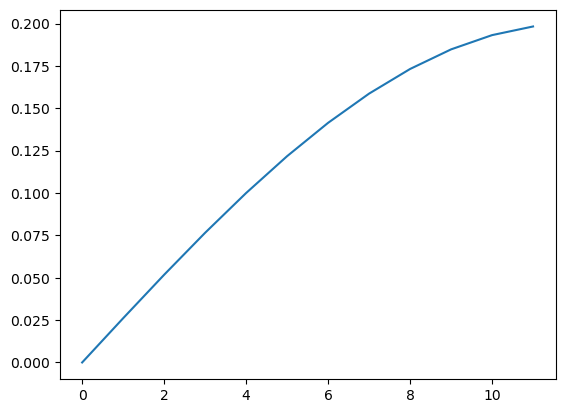

In [6]:

#Create inertial Currents

inertial_period = 12 #hours
#sigma = 200 #Spatial decay scale in km
#sigma_list = [50, 100, 200]
sigma_list = [200]
amp = 0.2
save_path = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/equator_currents/right_rotating"
for sigma in sigma_list:
    era_gaussian = make_gaussian_inertial_current(eranew_hf, inertial_period, sigma, amp)
    era_gaussian = make_div_rot_vels(era_gaussian) # add div and rot velocities
    era_gaussian.to_netcdf(save_path+"/equator_currents_"+str(sigma)+"_"+str(inertial_period).split('.')[0]+".nc")#+"_"+str(amp)+".nc")


    # #Create Steady current
    #dirs = ["northwest", "northeast", "southeast", "southwest"]
    #dirs = ["west", "north", "east", "south"]

    # # # dirs = ['west']
    # for dir in dirs:
    #     era_gaussian_steady = make_steady_current(eranew_hf, sigma, 0.2, dir)
    #     era_gaussian_steady = make_div_rot_vels(era_gaussian_steady) # add div and rot velocities
    #     era_gaussian_steady.to_netcdf(save_path+"/equator_currents_"+str(sigma)+"_"+"steady_"+dir+".nc")

#Create 1d x current
#era_gaussian_x = make_gaussian_inertial_current(era5, inertial_period, sigma, amp, dim="x")
#era_gaussian_y = make_gaussian_inertial_current(era5, inertial_period, sigma, amp, dim="y")

#Create 1d x steady current
#era_gaussian_x_steady = make_steady_current(era5, sigma, amp, "south", "x")
#era_gaussian_y_steady = make_steady_current(era5, sigma, amp, "south", "y")

#

[16]


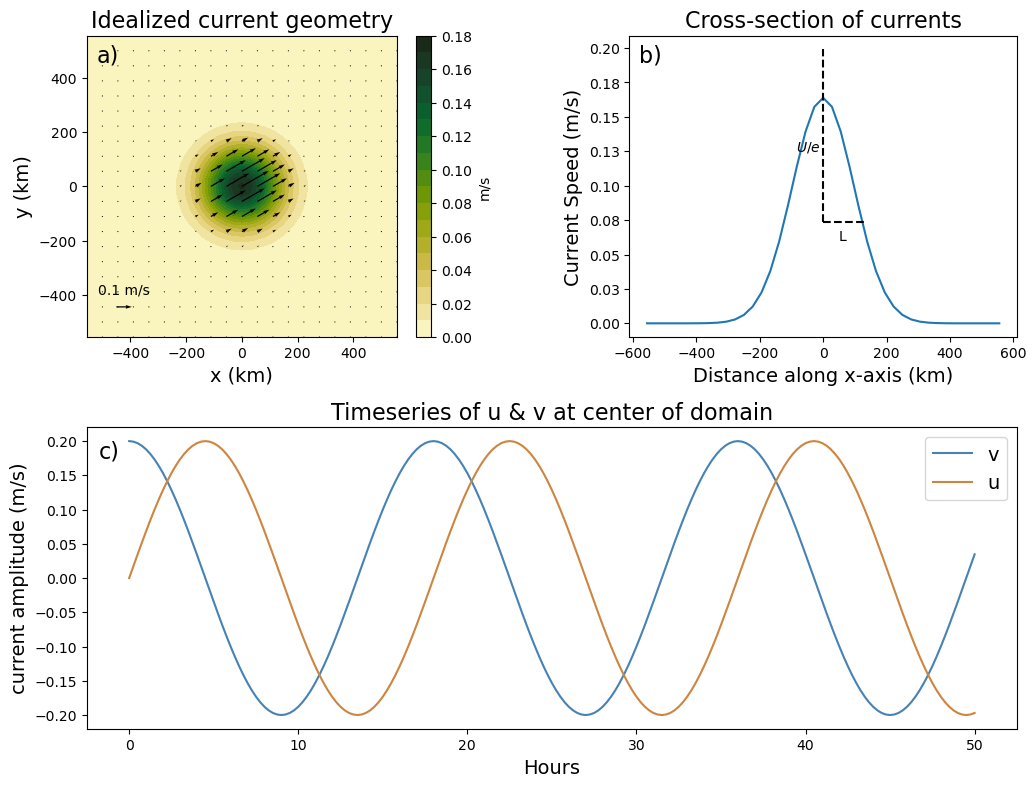

In [78]:
#Make Figure
import cmocean
ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, len(era_gaussian.latitude))
xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, len(era_gaussian.longitude))
dx = xkm[1]-xkm[0]
dy = ykm[1]-ykm[0]

ind = 20
plt.figure(figsize = (12, 9))

gs = gridspec.GridSpec(2, 2)
#gs.update(hspace=0.315)
#gs.update(wspace=1.5)

ax0 = plt.subplot(gs[0, 0])
ax1 = plt.subplot(gs[0, 1])
#ax2 = plt.subplot(gs[0, 2])
ax3 = plt.subplot(gs[1, :])

#index = 
im = ax0.contourf(xkm, ykm, era_gaussian.ucur[156, :, :], cmap=cmocean.cm.speed, levels=20)
q = ax0.quiver(xkm[::2], ykm[::2], era_gaussian.ucur[156, ::2, ::2], era_gaussian.vcur[156, ::2, ::2], scale=2, units='width', width=.004)
ax0.quiverkey(q, X=0.12, Y=0.1, U=0.1, label="0.1 m/s")
cbar = plt.colorbar(im)
cbar.ax.set_ylabel('m/s')
#ax0.set_xlim(-300, 300)
#ax0.set_ylim(-300, 300)
#plt.contourf(ucur_data[200, :, :])

temp = era_gaussian.ucur[155, :, :]
ax1.plot(xkm, temp[ind, :] )
fmax_ind = np.where(temp[ind, :]==np.max(temp[ind, :]))[0]
hmax_inds = np.where(abs(temp[ind, :]-np.max(temp[ind, :])/2)==np.min(abs(temp[ind, :]-np.max(temp[ind, :])/2)))[0]


print(hmax_inds)

fwidth = 2*(np.abs(xkm[hmax_inds][0]-xkm[fmax_ind][0]))
#ax1.annotate(r"$\sigma$ = " + str(np.round(fwidth/2.35)) +"km", (-100, temp[ind, hmax_inds[0]]/2))
ax1.annotate(r"L ", (50,0.06))
ax1.annotate(r"$U/e$", (-85,0.125))


#ax2.plot(ykm, temp[:, ind] )
hmax_inds = np.where(abs(temp[:, ind]-np.max(temp[:, ind])/np.e)==np.min(abs(temp[:, ind]-np.max(temp[:, ind])/np.e)))[0]


#ax[2].hlines(xmin=ykm[hmax_inds[0]], xmax=-1*ykm[hmax_inds[0]], y=temp[hmax_inds[0], 20])
#plt.scatter(xkm[hmax_inds], temp[20, hmax_inds])
fwidth = -1*ykm[hmax_inds][0]-ykm[hmax_inds][0]
hwidth = fwidth/2
#ax2.annotate(r"$\sigma$= " + str(np.round(fwidth/2.35)) +"km", (-100, temp[hmax_inds[0], ind]/2))
ax1.hlines(y=0.2/np.e, xmin=0, xmax=np.abs(hwidth), linestyle='--', color='k')
ax1.vlines(x=0, ymin=(0.2/np.e), ymax=0.199, linestyle='--', color='k')
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))

ax1.set_xlabel("Distance along x-axis (km)", fontsize=14)
ax1.set_ylabel("Current Speed (m/s)", fontsize=14)
ax0.set_xlabel("x (km)", fontsize=14)
ax0.set_ylabel("y (km)", fontsize=14)
#ax2.set_ylabel("m/s")
plt.subplots_adjust(wspace=0.4, hspace=0.3)

ax3.plot(np.linspace(0, 50, 201), era_gaussian.vcur[:201, ind, ind], label='v', color='steelblue')
ax3.plot(np.linspace(0, 50, 201), era_gaussian.ucur[:201, ind, ind], label='u', color='peru')
#ax3.set_xlim(0, 200)
ax3.set_xlabel("Hours", fontsize=14)
ax3.set_ylabel("current amplitude (m/s)", fontsize=14)
ax3.legend(fontsize=14)
ax0.set_title("Idealized current geometry", fontsize=16)
ax1.set_title("Cross-section of currents", fontsize=16)
ax3.set_title("Timeseries of u & v at center of domain", fontsize=16)

### Add (a), (b), (c) labels
ax0.annotate("a)", (-520, 460), fontsize=16)
ax1.annotate("b)", (-580, 0.19), fontsize=16)
ax3.annotate("c)", (-1.8, 0.175), fontsize=16)

#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/currents_"+str(sigma)+".png", dpi=300, bbox_inches='tight')




In [1]:
era_gaussian

NameError: name 'era_gaussian' is not defined

Text(0.5, 1.0, '$U_{rot}$')

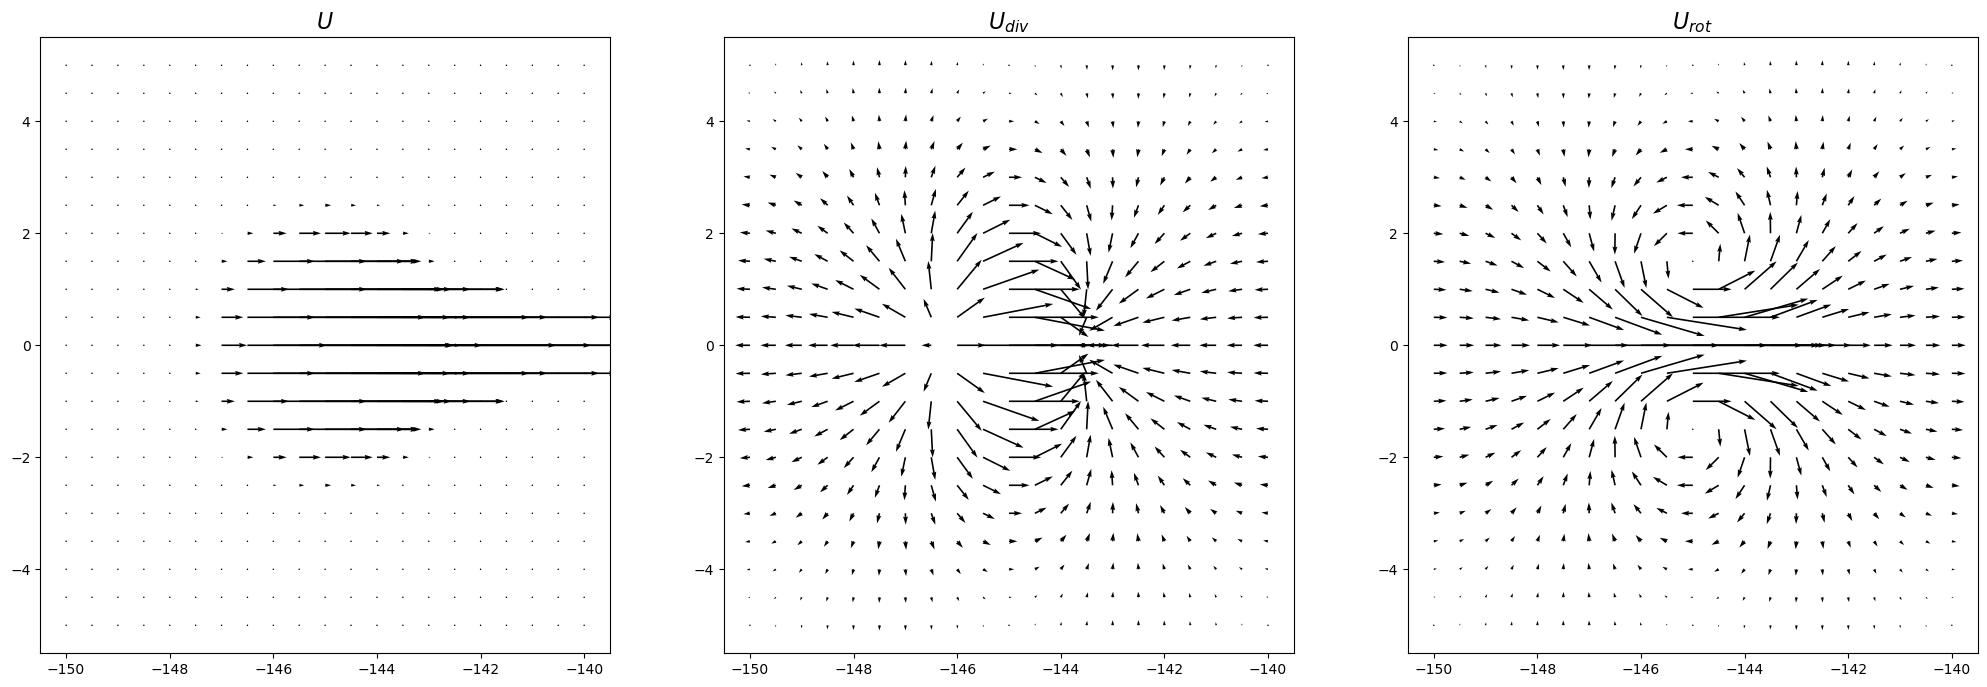

In [154]:
fig, ax = plt.subplots(1, 3, figsize=(25, 8))
tind = 156
ax[0].quiver(era_gaussian.longitude[::2], era_gaussian.latitude[::2], era_gaussian.ucur[tind,::2, ::2], era_gaussian.vcur[tind, ::2, ::2])
ax[0].set_title("$U$", fontsize=16)

ax[1].quiver(era_gaussian.longitude[::2], era_gaussian.latitude[::2], era_gaussian.u_div[tind, ::2, ::2], era_gaussian.v_div[tind, ::2, ::2])
ax[1].set_title("$U_{div}$", fontsize=16)

#cm1 = ax[0,1].contourf(vchi)
#ax[0,1].set_title("V $\chi$")

ax[2].quiver(era_gaussian.longitude[::2], era_gaussian.latitude[::2], era_gaussian.u_rot[tind, ::2, ::2], era_gaussian.v_rot[tind, ::2, ::2])
ax[2].set_title("$U_{rot}$", fontsize=16)

#cm3 = ax[1,1].contourf(vpsi)
#ax[1,1].set_title("V $\psi$")


#plt.colorbar(cm)
#plt.colorbar(cm1)
#plt.colorbar(cm2)
#plt.colorbar(cm3)

# Look at maps of inertial currents

In [125]:
era_gaussian.ucur[tind, :, :]

<xarray.DataArray 'ucur' (latitude: 41, longitude: 41)>
array([[-1.11297621e-15, -5.42072407e-15, -2.43426944e-14, ...,
        -2.43426944e-14, -5.42072407e-15, -1.11297621e-15],
       [-5.42072407e-15, -2.64015072e-14, -1.18560512e-13, ...,
        -1.18560512e-13, -2.64015072e-14, -5.42072407e-15],
       [-2.43426944e-14, -1.18560512e-13, -5.32416387e-13, ...,
        -5.32416387e-13, -1.18560512e-13, -2.43426944e-14],
       ...,
       [-2.43426944e-14, -1.18560512e-13, -5.32416387e-13, ...,
        -5.32416387e-13, -1.18560512e-13, -2.43426944e-14],
       [-5.42072407e-15, -2.64015072e-14, -1.18560512e-13, ...,
        -1.18560512e-13, -2.64015072e-14, -5.42072407e-15],
       [-1.11297621e-15, -5.42072407e-15, -2.43426944e-14, ...,
        -2.43426944e-14, -5.42072407e-15, -1.11297621e-15]])
Coordinates:
  * longitude  (longitude) float32 -150.0 -149.8 -149.5 ... -140.5 -140.2 -140.0
  * latitude   (latitude) float32 -5.0 -4.75 -4.5 -4.25 ... 4.25 4.5 4.75 5.0
    time       datetime64[ns] 2019-04-02T15:00:00

In [128]:
tind = 156
#w = VectorWind(era_gaussian.ucur[tind, :, :], era_gaussian.vcur[tind, :, :])
#sf, vp = w.sfvp()
u_x = era_gaussian.ucur[tind, :, :]
u_y = era_gaussian.vcur[tind, :, :]
import numpy as np
from scipy.sparse.linalg import cg
# 1. Compute div(u)
div_u = np.gradient(u_x, axis=1)+np.gradient(u_y, axis=0)
# 2. Solve Laplacian: laplacian(phi) = div_u, with Neumann BCs
phi = solve_poisson(div_u, boundary='neumann')
# 3. Compute gradient: grad(phi)
grad_x, grad_y = np.gradient(phi)
# 4. Solenoidal part
u_sol_x = u_x - grad_x
u_sol_y = u_y - grad_y


NameError: name 'solve_poisson' is not defined

In [135]:
u_x = era_gaussian.ucur[tind, :, :].values
u_y = era_gaussian.vcur[tind, :, :].values
lats = era_gaussian.latitude.values
lons = era_gaussian.longitude.values

(u_irrot, v_irrot), (u_sol, v_sol) = helmholtz_latlon_accurate(u_x, u_y, lats, lons)


Text(0.5, 1.0, '$U_{rot}+U_{div}$')

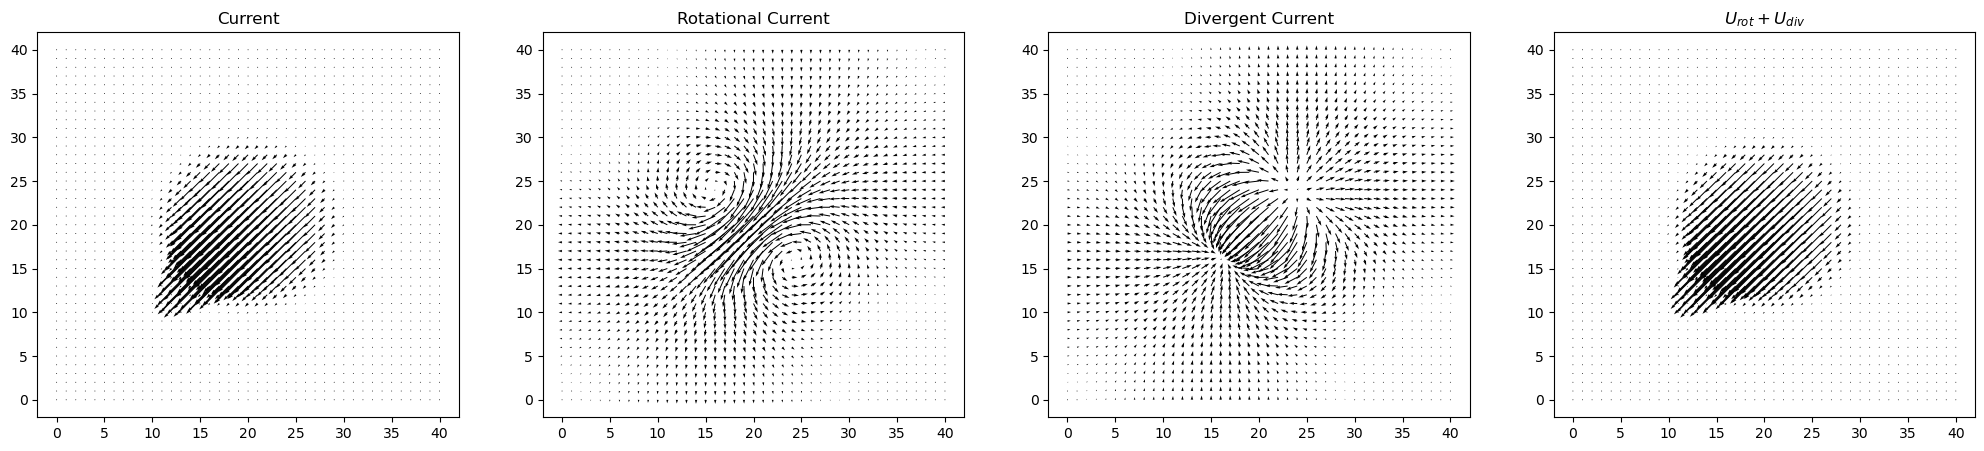

In [147]:
fig, ax = plt.subplots(1,4, figsize=(25, 5))
ax[0].quiver(era_gaussian.ucur[tind, :, :], era_gaussian.vcur[tind, :, :])
ax[1].quiver(u_sol,v_sol)
ax[2].quiver(u_irrot,v_irrot)
ax[3].quiver(u_sol+u_irrot, v_sol+v_irrot)
ax[0].set_title("Current")
ax[1].set_title("Rotational Current")
ax[2].set_title("Divergent Current")
ax[3].set_title("$U_{rot}+U_{div}$")

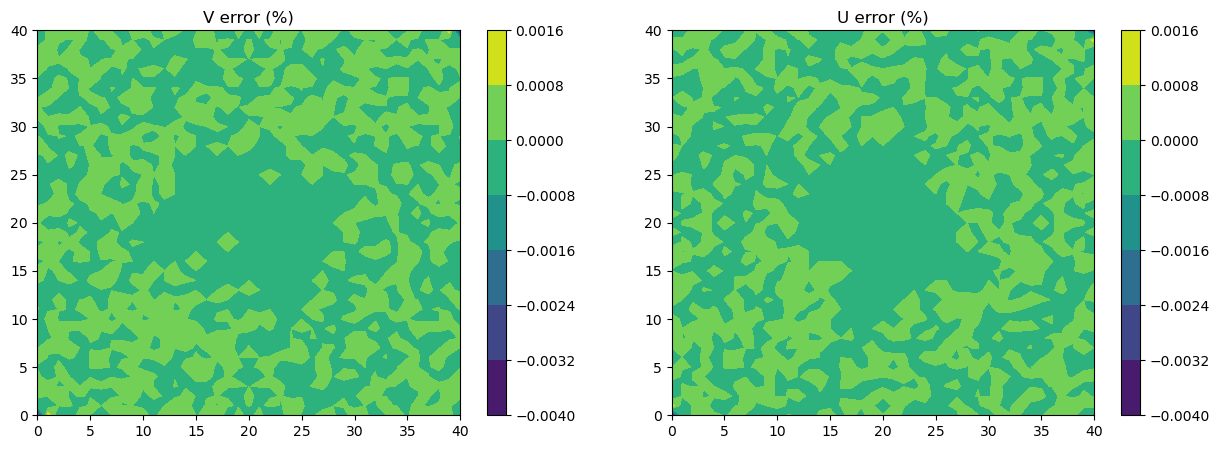

In [146]:
fig, ax = plt.subplots(1,2, figsize=(15, 5))

cm0 = ax[0].contourf(100*(v_sol+v_irrot-era_gaussian.vcur[tind, :, :])/era_gaussian.vcur[tind, :, :])
cm1 = ax[1].contourf(100*(u_sol+u_irrot-era_gaussian.ucur[tind, :, :])/era_gaussian.ucur[tind, :, :])
ax[1].set_title("U error (%)")
ax[0].set_title("V error (%)")
plt.colorbar(cm1)
plt.colorbar(cm0)

In [114]:
u = np.gradient(sf, axis=0) #dpsi/dy?
v = -np.gradient(sf, axis=1) #dpsi/dx?

ud = np.gradient(vp, axis=1) 
vd = np.gradient(vp, axis=0)

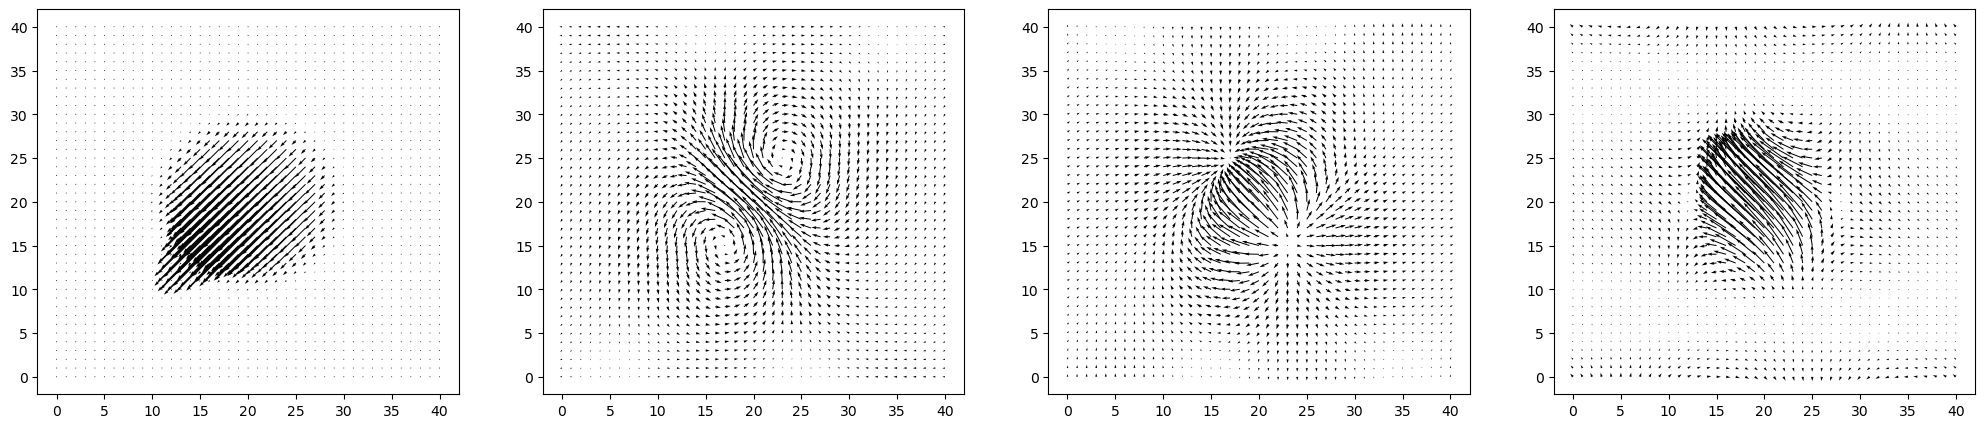

In [115]:
fig, ax = plt.subplots(1,4, figsize=(25, 5))
ax[0].quiver(era_gaussian.ucur[tind, :, :], era_gaussian.vcur[tind, :, :])
ax[1].quiver(u,v)
ax[2].quiver(ud,vd)
ax[3].quiver(u+ud, v+vd)

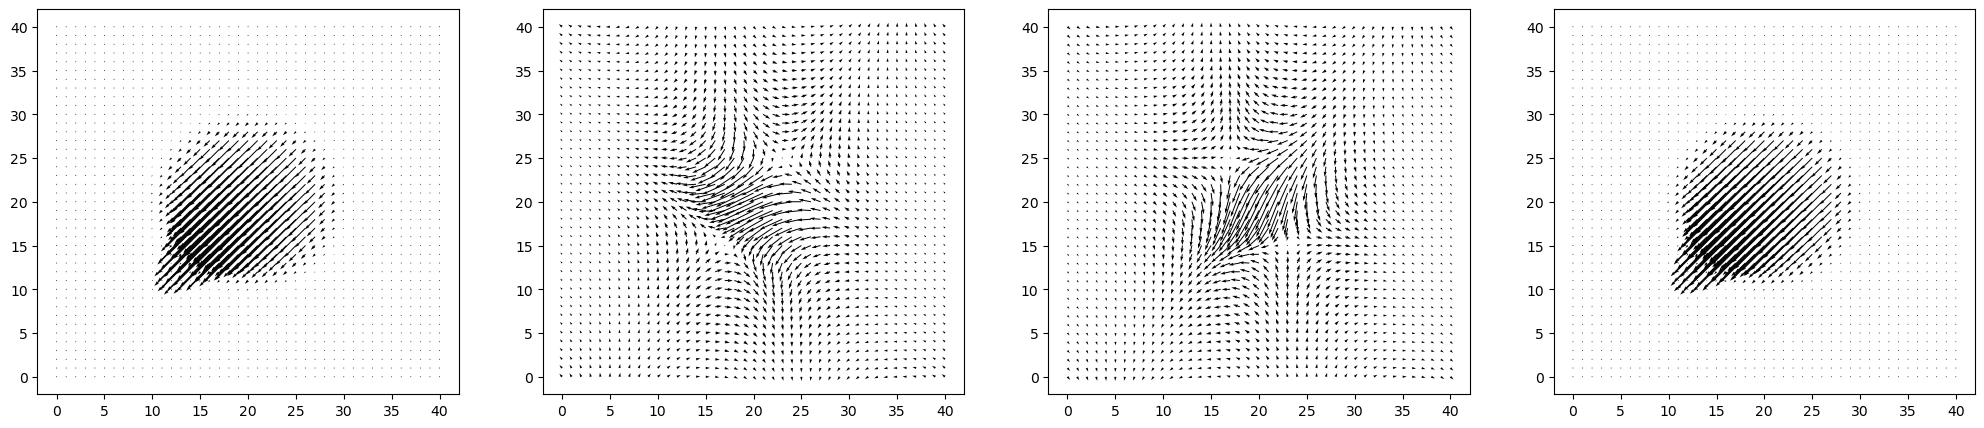

In [116]:
uchi, vchi, upsi, vpsi = w.helmholtz()
fig, ax = plt.subplots(1,4, figsize=(25, 5))
ax[0].quiver(era_gaussian.ucur[tind, :, :], era_gaussian.vcur[tind, :, :])
ax[1].quiver(upsi,vpsi)
ax[2].quiver(uchi,vchi)
ax[3].quiver(uchi+upsi, vchi+vpsi)

In [45]:
#Calculate spectrum

from scipy.signal.windows import hamming, hann
from scipy import signal
def calculate_omnidirectional_spec(anom):
    N = len(anom.longitude)-2
    dy = haversine((-5, -145), (5, -145), unit=Unit.METERS)/(N+2)
    dx = haversine((0, -150), (0, -140), unit=Unit.METERS)/(N+2)
    print(dx)
    
    #1. Demean
    anom = anom - np.nanmean(anom)

    # 2. Window data
    win1d = hann(N)
    window2d = np.outer(win1d, win1d)
    windowed_data = anom.values[1:len(anom.latitude)-1, 1:len(anom.longitude)-1] * window2d
    # 2. Compute 2D FFT
    fft_map = np.fft.fft2(windowed_data)
    fft_shifted = np.fft.fftshift(fft_map)
    power_spectrum = np.abs(fft_shifted)**2
    f, Pxx_spec = signal.welch(windowed_data, fs= 1/dx, nperseg=64, noverlap=32, axis=0)

    
    # 3. Define Wavenumber axes
    kx = np.fft.fftshift(np.fft.fftfreq(N, dx)) * 2 * np.pi
    ky = np.fft.fftshift(np.fft.fftfreq(N, dy)) * 2 * np.pi
    #print(kx)
    Kx, Ky = np.meshgrid(kx, ky)
    Kr = np.sqrt(Kx**2 + Ky**2)
    
    # 4. Radial Averaging (Omnidirectional)
    # Define bins for radial wavenumber
    k_min = 0
    k_max = np.max(Kr)
    num_bins = 64
    bins = np.linspace(k_min, k_max, num_bins)
    
    # Flatten the matrices to iterate
    Kr_flat = Kr.flatten()
    ps_flat = power_spectrum.flatten()
    
    # Bin the data
    bin_indices = np.digitize(Kr_flat, bins)
    bin_centers = (bins[1:] + bins[:-1]) / 2
    omnidirectional_spectrum = [ps_flat[bin_indices == i].mean() for i in range(1, len(bins))]

    #return(kx[40:], np.nanmean(power_spectrum, 0)[40:])
    #return(bin_centers, omnidirectional_spectrum)
    #Flipping so that kx and ky correspond correctly
    return(f, Pxx_spec)



In [22]:

era5 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_equator/era5_idealized_equator2.nc")


In [48]:
spec.shape

(33, 159)

In [41]:
t = np.arange(len(era5.time))
amp = 0.2
phase = 0
    #For inertial

    #To make left rotating inertial current, multiple ucur_arr by -1
ucur_arr = amp*np.sin(2*np.pi*(1/6)*t+phase)

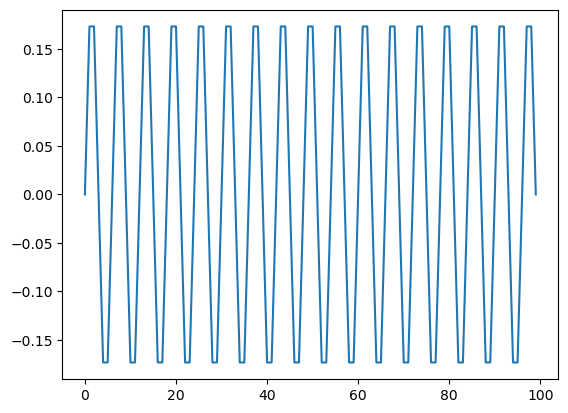

In [42]:
plt.plot(ucur_arr[0:100])

In [43]:
eranew = era5

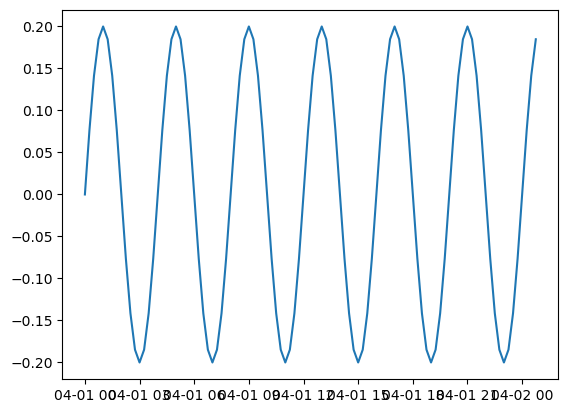

In [64]:
t = np.arange(len(eranew_hf.time))
amp = 0.2
phase = 0
    #For inertial
#if it's 15min intervals, the 6 hours * 4 = period of 24 time units
Ti = 4*4
    #To make left rotating inertial current, multiple ucur_arr by -1
ucur_arr = amp*np.sin(2*np.pi*(1/Ti)*t+phase)
plt.plot(eranew_hf.time[0:100], ucur_arr[0:100])

In [57]:
new_time = pd.date_range(start=era5.time.values[0], end=era5.time.values[-1], periods = 2928*4-3) #This is 1/4 hourly time
new_time

DatetimeIndex(['2019-04-01 00:00:00', '2019-04-01 00:15:00',
               '2019-04-01 00:30:00', '2019-04-01 00:45:00',
               '2019-04-01 01:00:00', '2019-04-01 01:15:00',
               '2019-04-01 01:30:00', '2019-04-01 01:45:00',
               '2019-04-01 02:00:00', '2019-04-01 02:15:00',
               ...
               '2019-07-31 20:45:00', '2019-07-31 21:00:00',
               '2019-07-31 21:15:00', '2019-07-31 21:30:00',
               '2019-07-31 21:45:00', '2019-07-31 22:00:00',
               '2019-07-31 22:15:00', '2019-07-31 22:30:00',
               '2019-07-31 22:45:00', '2019-07-31 23:00:00'],
              dtype='datetime64[ns]', length=11709, freq=None)

0.25

In [3]:
era5 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_equator/era5_idealized_equator2.nc")


In [4]:
era5

<xarray.Dataset>
Dimensions:    (longitude: 121, latitude: 81, time: 2928)
Coordinates:
  * longitude  (longitude) float32 -160.0 -159.8 -159.5 ... -130.5 -130.2 -130.0
  * latitude   (latitude) float32 -10.0 -9.75 -9.5 -9.25 ... 9.25 9.5 9.75 10.0
  * time       (time) datetime64[ns] 2019-04-01 ... 2019-07-31T23:00:00
Data variables:
    u10        (time, latitude, longitude) float32 ...
    v10        (time, latitude, longitude) float32 ...
    mwd        (time, latitude, longitude) float32 ...
    mwp        (time, latitude, longitude) float32 ...
    swh        (time, latitude, longitude) float32 ...
    mdts       (time, latitude, longitude) float32 ...
    mpts       (time, latitude, longitude) float32 ...
    msqs       (time, latitude, longitude) float32 ...
    pp1d       (time, latitude, longitude) float32 ...
    shts       (time, latitude, longitude) float32 ...
    shww       (time, latitude, longitude) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      2026-01-07 23:32:47 GMT by grib_to_netcdf-2.42.0: grib_to_n...

In [85]:
#
era5 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/equator_currents/equator_currents_100_12.nc")


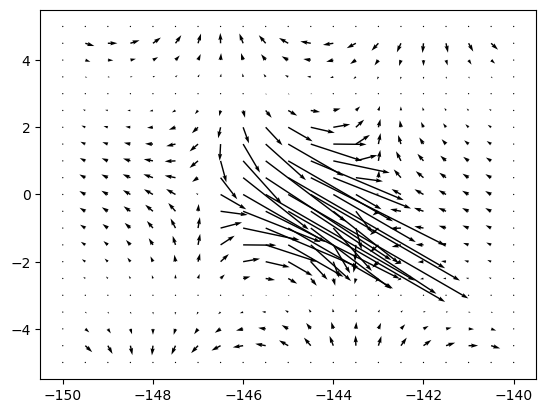

In [90]:
plt.quiver(era5.longitude[::2], era5.latitude[::2], era5.u_div[200, ::2, ::2]+era5.u_rot[200,::2, ::2], era5.v_div[200, ::2, ::2]+era5.v_rot[200,::2, ::2])





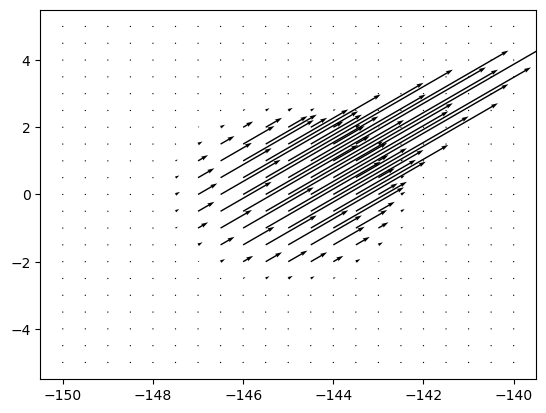

In [92]:
plt.quiver(era5.longitude[::2], era5.latitude[::2], era5.ucur[200, ::2, ::2], era5.vcur[200, ::2, ::2])


In [19]:
"""
Test spectra of smoother gaussian
"""

x_size=1000
y_size=1000
x = np.linspace(-x_size/2, x_size/2, x_size)
y = np.linspace(-y_size/2, y_size/2, y_size)
# Create the 2D coordinate grids
X, Y = np.meshgrid(x, y)
D = np.sqrt((X)**2 + (Y)**2)
spatial_decay = 100


ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, x_size)
xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, y_size)
dx = xkm[1]-xkm[0]
dy = ykm[1]-ykm[0]


sigma =  spatial_decay/(dx) # Standard deviation (controls spread) - converts from km units to in terms of grid points
gaussian = 1/(2*np.pi*sigma) * np.exp(-((X)**2 / (2.0 * sigma**2)))

In [20]:
import scipy
fcur, pxxcur = scipy.signal.welch(gaussian[500, :], fs = 1/(x[3]-x[2]))
fcur2, pxxcur2 = scipy.signal.welch(gaussian[500, ::10], fs = 1/(x[::10][2]-x[::10][1]))

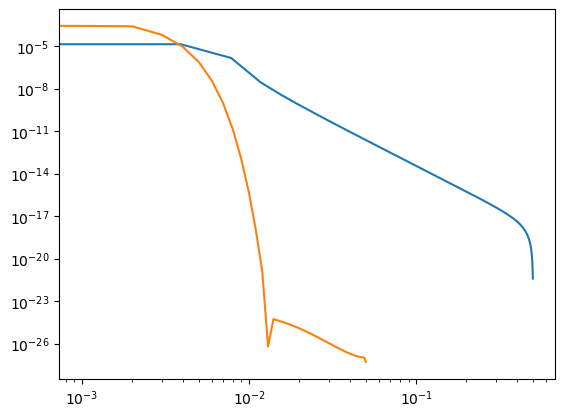

In [21]:
plt.loglog(fcur, pxxcur)
plt.loglog(fcur2, pxxcur2)

In [22]:
x[3]-x[2]

1.0010010010009864

-496.996996996997

In [24]:
x[::10][2]-x[::10][1]

10.010010010009978